### Наивный байесовский классификатор

**Наивный байесовский классификатор** - это алгоритм классификации, который использует теорему Байеса и предполагает, что все признаки объекта независимы при условии известного класса. Несмотря на упрощенное допущение, метод показывает высокую эффективность и широко применяется на практике.

## Используемые библиотеки

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

## Используемый датасет

In [16]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].apply(lambda x: iris.target_names[x])

print("Первые 5 строк датасета:")
print(df.head())

print("\nРазмерность датасета:", df.shape)
print("\nСтатистика по признакам:")
print(df.describe())

Первые 5 строк датасета:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Размерность датасета: (150, 6)

Статистика по признакам:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000 

## Обработка датасета

In [17]:
print("Проверка на пропуски:")
print(df.isnull().sum())

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} образцов")
print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")

Проверка на пропуски:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Размер обучающей выборки: 105 образцов
Размер тестовой выборки: 45 образцов


## Тепловая карта

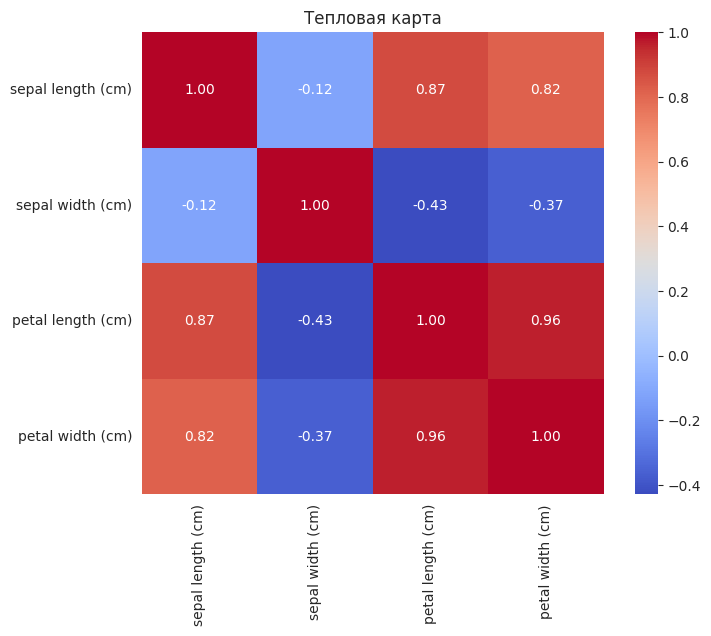

In [18]:
corr_matrix = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            cbar=True)
plt.title('Тепловая карта')
plt.show()

## Обучение модели

In [19]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

print("Модель обучена:")
print(f"Классы: {gnb.classes_}")
print(f"Вероятности классов: {gnb.class_prior_}")

Модель обучена:
Классы: [0 1 2]
Вероятности классов: [0.33333333 0.33333333 0.33333333]


## Прогнозы модели

In [20]:
y_pred = gnb.predict(X_test)

print("Сравнение первый 10 реальных значений и предсказаний:")
for i in range(10):
    print(f"Реальный: {iris.target_names[y_test[i]]:10} | Предсказанный: {iris.target_names[y_pred[i]]:10}")

y_pred_proba = gnb.predict_proba(X_test)
print(f"\nВероятности для первых 5 образцов (0-setosa, 1-versicolor, 2-virginica):")
print(np.round(y_pred_proba[:5], 3))

Сравнение первый 10 реальных значений и предсказаний:
Реальный: virginica  | Предсказанный: virginica 
Реальный: versicolor | Предсказанный: versicolor
Реальный: virginica  | Предсказанный: versicolor
Реальный: versicolor | Предсказанный: versicolor
Реальный: virginica  | Предсказанный: virginica 
Реальный: virginica  | Предсказанный: virginica 
Реальный: versicolor | Предсказанный: versicolor
Реальный: versicolor | Предсказанный: versicolor
Реальный: setosa     | Предсказанный: setosa    
Реальный: virginica  | Предсказанный: virginica 

Вероятности для первых 5 образцов (0-setosa, 1-versicolor, 2-virginica):
[[0.    0.    1.   ]
 [0.    0.996 0.004]
 [0.    0.847 0.153]
 [0.    0.668 0.332]
 [0.    0.104 0.896]]


## Графики выходных результатов

Точность модели на тестовых данных: 0.91

Отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



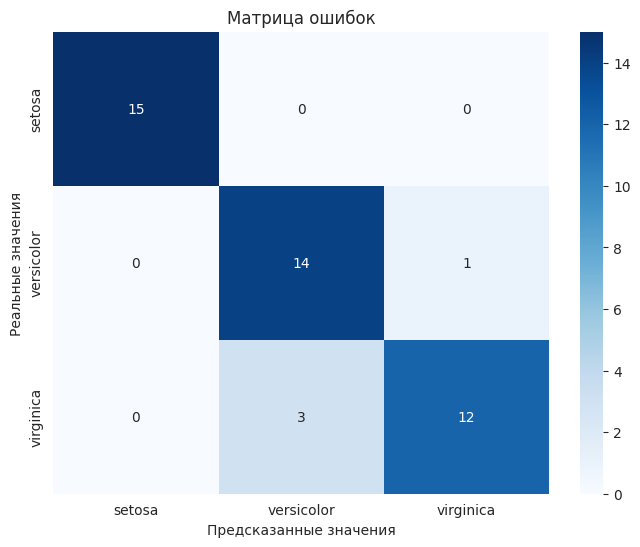

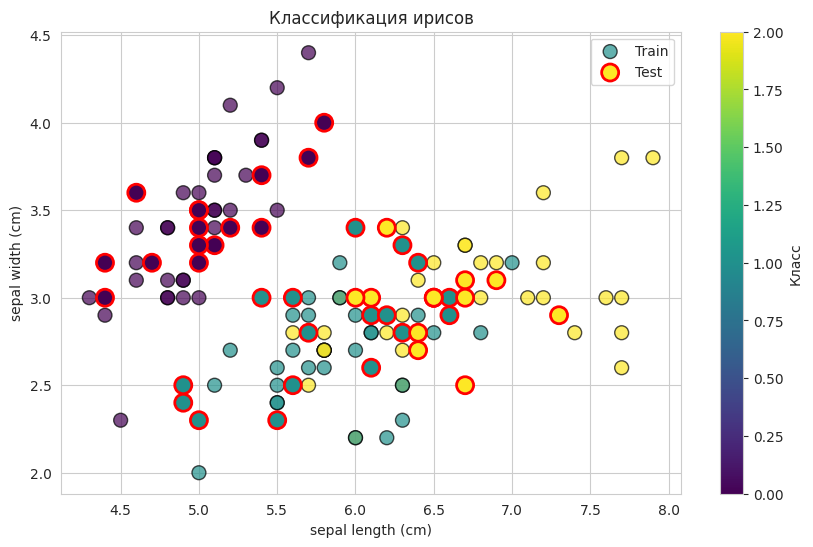

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели на тестовых данных: {accuracy:.2f}")

print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Матрица ошибок')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

plt.figure(figsize=(10, 6))

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=100, alpha=0.7, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', marker='o', s=150, edgecolors='red', linewidth=2, label='Test')

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Классификация ирисов')
plt.legend()
plt.colorbar(label='Класс')
plt.show()